# 08 — AURN reference validation

Two DEFRA AURN reference stations sit inside the study area, downloaded via `src/aurn_reader.py` (DEFRA's flat CSV files, not the RData route — `pyreadr` cannot parse DEFRA's current RData export; see the module docstring). Their official DEFRA classification happens to match the two outer tiers of the Lenschow et al. (2001) regional/urban/local decomposition used in notebook 07:

| Site | Code | DEFRA type | PM2.5 method |
|---|---|---|---|
| Leeds Centre | `LEED` | Urban Background | FIDAS |
| Headingley Kerbside | `LED6` | Urban Traffic | BAM |

This notebook does three things: (1) downloads and sanity-checks both records; (2) finds the nearest PurpleAir sensor to each and checks the Barkjohn-corrected values against real reference instruments, which is the local ground-truth check the dissertation has flagged as missing since Milestone 2; (3) computes a genuine kerbside-minus-background traffic increment from the two reference stations and checks it against the network-derived traffic index from notebook 07.

**Run this notebook's download cell on a machine with normal internet access** — `uk-air.defra.gov.uk` is the target, which is a different network path from the OneDrive folder the PurpleAir pipeline reads.

In [5]:
import re
import sys
from pathlib import Path

def find_project_root(start: Path, marker: str = "src") -> Path:
    """Walk upward from `start` until a folder containing `marker/` is
    found. More robust than assuming a fixed offset like Path.cwd().parent,
    which breaks if the kernel's working directory isn't exactly what an
    editor defaults to (observed across a kernel restart in VS Code)."""
    for candidate in [start, *start.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(
        f"couldn't find a '{marker}/' folder anywhere above {start} -- "
        f"is this notebook running from inside the project?"
    )

project_root = find_project_root(Path.cwd())
sys.path.append(str(project_root))
print("kernel working directory:", Path.cwd())
print("project root found at:   ", project_root)

from src.config import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Force-refresh both modules regardless of anything this kernel already had
# cached from earlier in the session.
import importlib
import src.aurn_reader, src.baseline
importlib.reload(src.aurn_reader)
importlib.reload(src.baseline)
from src.aurn_reader import download_defra_site, read_defra_flat_csv
from src.baseline import haversine_km, diurnal_profile

# Keep everything auto-refreshed for the rest of this session from here on.
%load_ext autoreload
%autoreload 2

def short_code(name: str) -> str:
    m = re.search(r"SL_?(\d+)", str(name))
    return f"SL{int(m.group(1)):03d}" if m else str(name)

AURN_SITES = {
    "LEED": {"name": "Leeds Centre",        "lat": 53.803780, "lon": -1.546472, "type": "urban background"},
    "LED6": {"name": "Headingley Kerbside", "lat": 53.819972, "lon": -1.576361, "type": "urban traffic"},
}
AURN_YEARS = range(2022, 2027)   # matches the PurpleAir study period
AURN_CACHE = PROJECT_ROOT / "data" / "raw" / "aurn"

print("loaded aurn_reader from:", src.aurn_reader.__file__)
print("has the header-detection fix:", hasattr(src.aurn_reader, "_find_header_row"))
print("AURN_SITES defined:", list(AURN_SITES.keys()))


kernel working directory: c:\Users\user\Desktop\University\Dissertation\Dissertation Sensing Leeds Air Quality\notebooks
project root found at:    c:\Users\user\Desktop\University\Dissertation\Dissertation Sensing Leeds Air Quality
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
loaded aurn_reader from: c:\Users\user\Desktop\University\Dissertation\Dissertation Sensing Leeds Air Quality\src\aurn_reader.py
has the header-detection fix: True
AURN_SITES defined: ['LEED', 'LED6']


## 1  Download and check both stations

Cached to `data/raw/aurn/` on first run — re-running this cell afterwards reads the local files instead of hitting DEFRA again.

In [6]:
aurn = {}
for code_, meta in AURN_SITES.items():
    print(f"--- {meta['name']} ({code_}) ---")
    df = download_defra_site(code_, AURN_YEARS, out_dir=AURN_CACHE, site_name=meta["name"])
    aurn[code_] = df
    print()

for code_, df in aurn.items():
    pm25_col = [c for c in df.columns if c.startswith("PM2.5")
               and not c.endswith(("_status", "_unit"))]
    if not pm25_col:
        print(f"! {code_}: no PM2.5 column found — check the site code")
        continue
    col = pm25_col[0]
    ratified = df[df[f"{col}_status"] == "R"]
    print(f"{AURN_SITES[code_]['name']}: {df['date'].min()} -> {df['date'].max()}, "
          f"{df[col].notna().sum():,} hours with PM2.5 "
          f"({ratified[col].notna().sum():,} Ratified, "
          f"{100*ratified[col].notna().sum()/max(df[col].notna().sum(),1):.0f}%)")

--- Leeds Centre (LEED) ---
  LEED 2022: 8,760 hours, 8,701 with PM2.5
  LEED 2023: 8,760 hours, 8,746 with PM2.5
  LEED 2024: 8,784 hours, 8,295 with PM2.5
  LEED 2025: 8,760 hours, 8,754 with PM2.5
  LEED 2026: 4,992 hours, 4,990 with PM2.5

--- Headingley Kerbside (LED6) ---
  LED6 2022: 8,760 hours, 8,426 with PM2.5
  LED6 2023: 8,760 hours, 7,454 with PM2.5
  LED6 2024: 8,784 hours, 8,573 with PM2.5
  LED6 2025: 8,760 hours, 8,548 with PM2.5
  LED6 2026: 4,992 hours, 4,687 with PM2.5

Leeds Centre: 2022-01-01 00:00:00 -> 2026-07-27 23:00:00, 39,486 hours with PM2.5 (36,654 Ratified, 93%)
Headingley Kerbside: 2022-01-01 00:00:00 -> 2026-07-27 23:00:00, 37,688 hours with PM2.5 (35,056 Ratified, 93%)


## 2  Nearest PurpleAir sensor to each AURN site

The single nearest sensor drives the main comparison, but the four nearest are shown as context — a comparison built on one sensor is only as good as that sensor happens to be, so it is worth seeing what else is close by.

In [7]:
sensors = pd.read_csv(OUT_TABLES / "study_sensors.csv")
sensors["code"] = sensors["sensor_name"].map(short_code)

nearest = {}
for code_, meta in AURN_SITES.items():
    d = haversine_km(meta["lat"], meta["lon"],
                     sensors["lat"].to_numpy(), sensors["lon"].to_numpy())
    ranked = (sensors.assign(km=d)[["code", "km"]]
             .sort_values("km").reset_index(drop=True))
    nearest[code_] = ranked
    print(f"Nearest PurpleAir sensors to {meta['name']} ({code_}):")
    print(ranked.head(4).round(3).to_string(index=False))
    print()

Nearest PurpleAir sensors to Leeds Centre (LEED):
 code    km
SL031 0.266
SL027 0.663
SL056 0.688
SL003 0.902

Nearest PurpleAir sensors to Headingley Kerbside (LED6):
 code    km
SL026 0.418
SL040 1.096
SL005 1.444
SL027 2.066



## 3  Calibration check: Barkjohn-corrected PurpleAir vs AURN reference

Both series are aggregated to hourly means (the AURN data already is; the PurpleAir side uses the same `MIN_READ_PER_HOUR` rule as notebooks 06 and 07) and joined on hour-start timestamps — `aurn_reader` already converts DEFRA's hour-ending labels to match. This is the first check in the whole project against an instrument that is not itself a PurpleAir, so agreement here means something the CSI cannot show on its own.

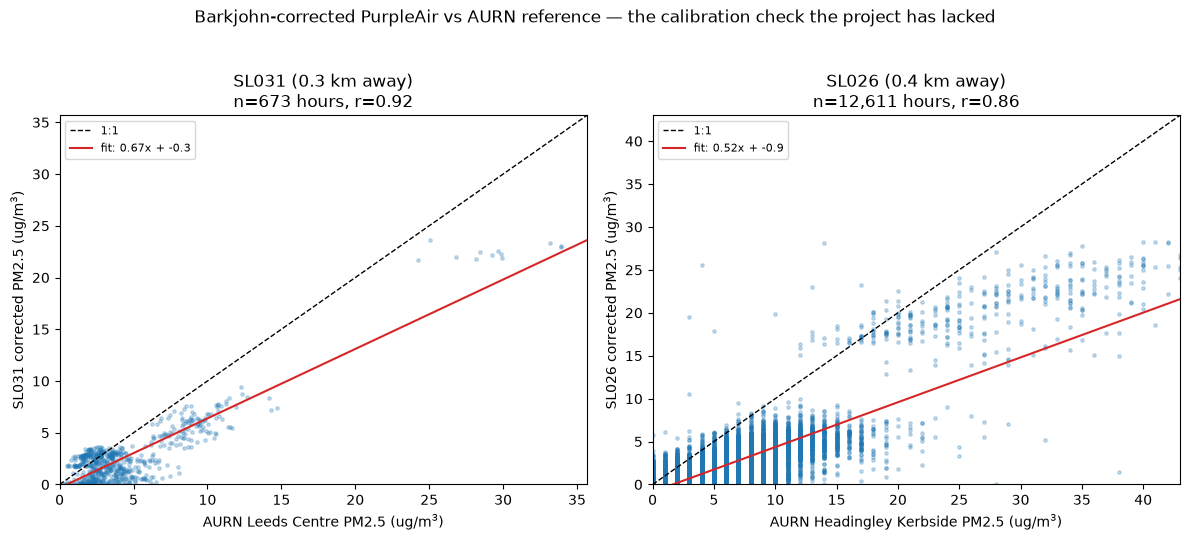

,aurn_site,nearest_sensor,distance_km,n_hours,slope,intercept,pearson_r
LEED,Leeds Centre,SL031,0.27,673,0.671,-0.32,0.921
LED6,Headingley Kerbside,SL026,0.42,12611,0.522,-0.86,0.859


In [8]:
from src.cleaning import apply_humidity_correction

def sensor_hourly(sensor_code_or_name):
    """Hourly mean of Barkjohn-corrected PM2.5 for one sensor, from its
    cleaned parquet -- same rule (MIN_READ_PER_HOUR) as notebooks 06/07."""
    matches = list(CLEANED.glob(f"*{sensor_code_or_name}*.parquet"))
    if not matches:
        return None, None
    path = matches[0]
    df = pd.read_parquet(path)
    clean = df[df["is_clean"]].copy()
    clean[DATE_COL] = pd.to_datetime(clean[DATE_COL], utc=True)
    clean["pm25_corr"] = apply_humidity_correction(clean)
    clean = clean.dropna(subset=["pm25_corr"])
    agg = clean.set_index(DATE_COL)["pm25_corr"].resample("h").agg(["mean", "count"])
    return agg.loc[agg["count"] >= MIN_READ_PER_HOUR, "mean"], path.stem


calib_rows = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

for ax, code_ in zip(axes, AURN_SITES):
    meta = AURN_SITES[code_]
    nearest_code = nearest[code_].iloc[0]["code"]
    nearest_km = nearest[code_].iloc[0]["km"]

    pm_col = [c for c in aurn[code_].columns if c.startswith("PM2.5")
             and not c.endswith(("_status", "_unit"))][0]
    ref = aurn[code_].set_index("date")[pm_col]
    ref.index = ref.index.tz_localize("UTC")  # DEFRA times are GMT, i.e. UTC year-round (no BST shift)

    pa_hourly, pa_file = sensor_hourly(nearest_code)
    if pa_hourly is None:
        print(f"! could not find a cleaned parquet for {nearest_code}")
        continue

    joined = pd.DataFrame({"aurn": ref, "purpleair": pa_hourly}).dropna()
    if len(joined) < 100:
        print(f"! only {len(joined)} overlapping hours for {nearest_code} vs {code_}, "
              f"too few for a reliable fit")
        continue

    slope, intercept = np.polyfit(joined["aurn"], joined["purpleair"], 1)
    r = joined[["aurn", "purpleair"]].corr().iloc[0, 1]
    calib_rows[code_] = {
        "aurn_site": meta["name"], "nearest_sensor": nearest_code,
        "distance_km": round(nearest_km, 2), "n_hours": len(joined),
        "slope": round(slope, 3), "intercept": round(intercept, 2),
        "pearson_r": round(r, 3),
    }

    ax.scatter(joined["aurn"], joined["purpleair"], s=6, alpha=0.25)
    lim = max(joined["aurn"].quantile(0.995), joined["purpleair"].quantile(0.995))
    ax.plot([0, lim], [0, lim], "k--", lw=1, label="1:1")
    xs = np.linspace(0, lim, 50)
    ax.plot(xs, slope * xs + intercept, color="tab:red", lw=1.5,
            label=f"fit: {slope:.2f}x + {intercept:.1f}")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(f"AURN {meta['name']} PM2.5 (ug/m$^3$)")
    ax.set_ylabel(f"{nearest_code} corrected PM2.5 (ug/m$^3$)")
    ax.set_title(f"{nearest_code} ({nearest_km:.1f} km away)\n"
                f"n={len(joined):,} hours, r={r:.2f}")
    ax.legend(fontsize=8)

fig.suptitle("Barkjohn-corrected PurpleAir vs AURN reference — the calibration check "
             "the project has lacked", y=1.03)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "aurn_calibration_check.png", dpi=200, bbox_inches="tight")
plt.show()

calib = pd.DataFrame(calib_rows).T
calib.to_csv(OUT_TABLES / "aurn_calibration_check.csv")
calib

## 4  A real traffic increment: kerbside minus urban background

Headingley Kerbside minus Leeds Centre, both reference-grade, is a genuine Lenschow-style traffic increment — no proxy involved. Compared against the traffic index built from the PurpleAir network in notebook 07 (the weekday-minus-weekend increment during commuting hours), agreement between the two would mean the network-derived traffic signal is not an artefact of the quantile-baseline method, since this comparison does not use that method at all.

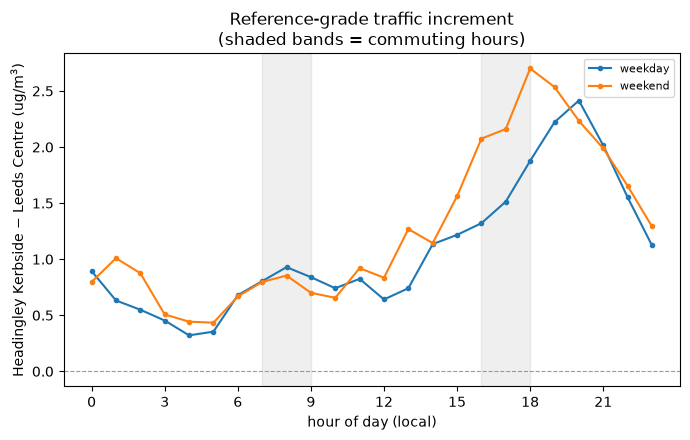

AURN reference traffic index (weekday - weekend, commuting hours): -0.34 ug/m3
Compare this to the roadside rows of outputs/tables/traffic_index_by_sensor.csv from notebook 07.


In [9]:
leed_col = [c for c in aurn["LEED"].columns if c.startswith("PM2.5")
           and not c.endswith(("_status", "_unit"))][0]
led6_col = [c for c in aurn["LED6"].columns if c.startswith("PM2.5")
           and not c.endswith(("_status", "_unit"))][0]

leed_s = aurn["LEED"].set_index("date")[leed_col]
led6_s = aurn["LED6"].set_index("date")[led6_col]

traffic_incr = (led6_s - leed_s).dropna()
traffic_incr.index = traffic_incr.index.tz_localize("UTC").tz_convert(LOCAL_TZ)

from src.baseline import diurnal_profile
prof = diurnal_profile(traffic_incr, tz=LOCAL_TZ, by_daytype=True, stat="median")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(prof.index, prof["weekday"], marker="o", ms=3, label="weekday")
ax.plot(prof.index, prof["weekend"], marker="o", ms=3, label="weekend")
ax.axhline(0, color="0.6", lw=0.8, ls="--")
ax.axvspan(7, 9, color="tab:grey", alpha=0.12)
ax.axvspan(16, 18, color="tab:grey", alpha=0.12)
ax.set_xlabel("hour of day (local)"); ax.set_xticks(range(0, 24, 3))
ax.set_ylabel("Headingley Kerbside \u2212 Leeds Centre (ug/m$^3$)")
ax.set_title("Reference-grade traffic increment\n(shaded bands = commuting hours)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "aurn_traffic_increment.png", dpi=200, bbox_inches="tight")
plt.show()

commute_wd = prof.loc[[7, 8, 9, 16, 17, 18], "weekday"].median()
commute_we = prof.loc[[7, 8, 9, 16, 17, 18], "weekend"].median()
print(f"AURN reference traffic index (weekday - weekend, commuting hours): "
      f"{commute_wd - commute_we:.2f} ug/m3")
print("Compare this to the roadside rows of outputs/tables/traffic_index_by_sensor.csv "
      "from notebook 07.")

## Summary

Fill in once run:

- the nearest sensor to each AURN site sits __ km away; the calibration fit gives slope __, intercept __, r = __, which __ (does / does not) support the Barkjohn correction as applied here;
- the reference-grade traffic increment during commuting hours is __ µg/m³, compared with __ µg/m³ from the network-derived traffic index in notebook 07 — __ (consistent / inconsistent), which __ (does / does not) corroborate the diurnal source-attribution result.